In [55]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [107]:
def f(x):
    return 2*x**3 - 4*x**2 + x + 8

In [108]:
f(3.0)

29.0

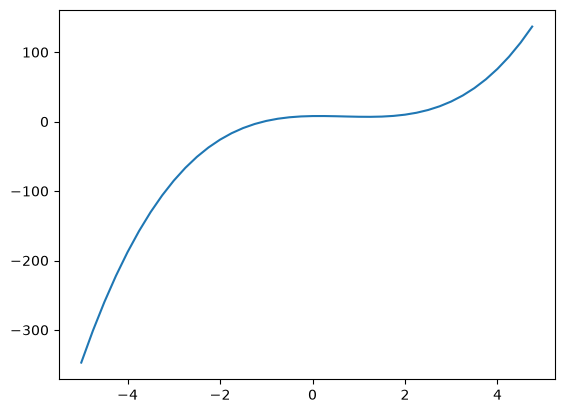

In [109]:
x_ax = np.arange(-5, 5, 0.25)
y_ax = f(x_ax)
plt.plot(x_ax, y_ax)

In [110]:
h = 0.000000001
x = 0.13969
(f(x + h) - f(x))/h

-0.00044053649617126206

In [111]:
def g(x, y, z):
    return x * y + z

# change
h = 0.00001

# inputs
a = 2.0
b = -3.0
c = 10.0

s1 = g(a, b, c)
a += h # should cause negative slope
s2 = g(a, b, c)

print('s1', s1)
print('s2', s2)
print('slope', (s2 - s1)/h)

s1 4.0
s2 3.9999699999999994
slope -3.000000000064062


In [112]:
from graphviz import Digraph

# does not quite give the same result, but did not debug

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
        
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

In [312]:
# Value -> Tensor equivalent for scalar values
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.label = label
        self.grad = 0.0

    def backward(self):
        self.grad = 1.0
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        for node in reversed(topo):
            node._backward()

    def exp(self):
        out = Value(math.exp(self.data), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        n = self.data
        t = (math.exp(2 * n) - 1) / (math.exp(2 * n) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other): # self ** other
        assert isinstance(other, (float, int)), "only float/int supported currently"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad  += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __add__(self, other): # self + other
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __radd__(self, other): # other + self
        return self + other # needs to be written in the order to prevent recursion error

    def __mul__(self, other): # self * other
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def __rmul__(self, other): # other * self
        return self * other # needs to be written in the order to prevent recursion error

    def __truediv__(self, other): # self / other
        return self * (other ** -1)

    def __rtruediv__(self, other): # other / self
        return other * (self ** -1)

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)
    
    def __repr__(self):
        return f"Value(data={self.data})"

In [114]:
a = Value(2.0)
b = Value(4.0)
1 - b

Value(data=-3.0)

In [115]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
d = a * b; d.label = 'd'
e = c + d; e.label = 'e'
f = Value(-2.0, label='f')
L = e * f; L.label = 'L'

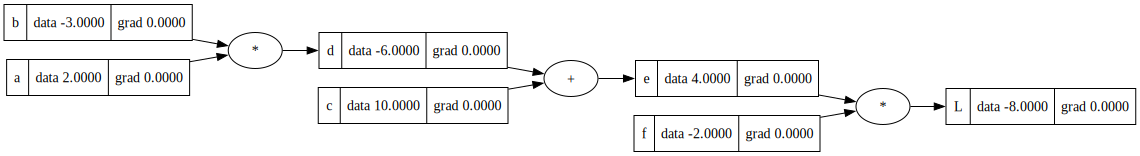

In [116]:
draw_dot(L)

In [117]:
L.grad = 1.0
e.grad = -2.0
f.grad = 4.0
c.grad = -2.0
d.grad = -2.0
a.grad = 6.0
b.grad = -4.0

In [118]:
# increase in the direction of gradient
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

# forward pass and expect increase
d = a * b
e = c + d
L = e * f

print(L.data)

-7.286496


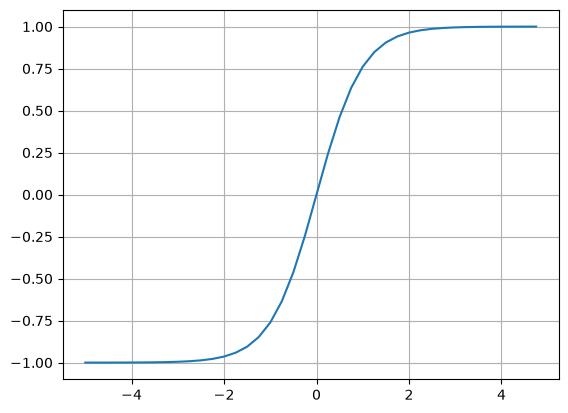

In [120]:
plt.plot(x_ax, np.tanh(x_ax)); plt.grid()

In [121]:
# inputs: x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights: w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron: b
b = Value(6.8813735870194532, label='b')
# weighted input 1: x1w1
x1w1 = x1 * w1; x1w1.label = 'x1w1'
# weighted input 2: x2w2
x2w2 = x2 * w2; x2w2.label = 'x2w2'
# sum of weighted inputs
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1+x2w2'
# bias added to sum of weighted inputs
n = x1w1x2w2 + b; n.label = 'n'
# activation function: tanh()
o = n.tanh(); o.label = 'o'
# backward pass
o.backward()

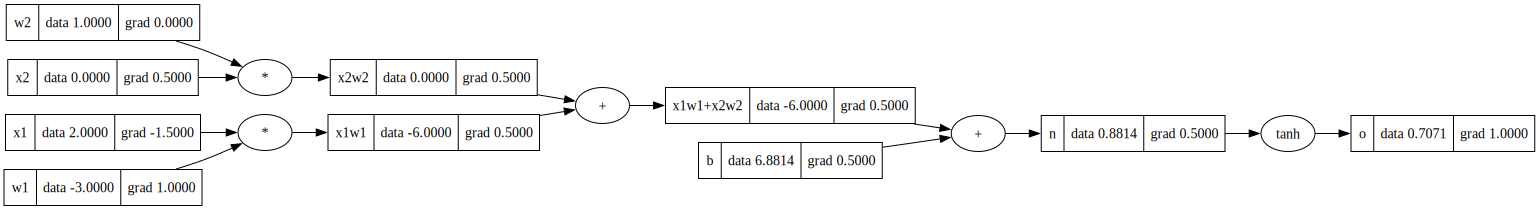

In [122]:
draw_dot(o)

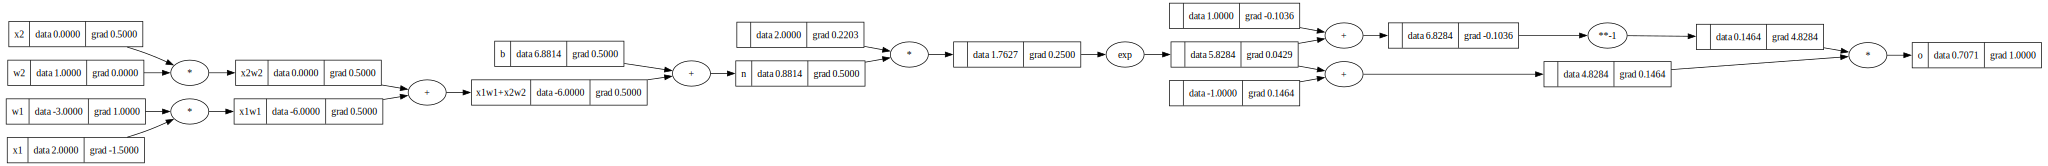

In [123]:
# inputs: x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights: w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron: b
b = Value(6.8813735870194532, label='b')
# weighted input 1: x1w1
x1w1 = x1 * w1; x1w1.label = 'x1w1'
# weighted input 2: x2w2
x2w2 = x2 * w2; x2w2.label = 'x2w2'
# sum of weighted inputs
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1+x2w2'
# bias added to sum of weighted inputs
n = x1w1x2w2 + b; n.label = 'n'
# activation function: breaking up tanh into (e^2x-1)/(e^2x+1)
e = (2 * n).exp()
o = (e - 1) / (e + 1)
# output label
o.label = 'o'
# backward pass
o.backward()
# draw graph
draw_dot(o)

In [124]:
import torch

In [125]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870194532]).double()  ; b.requires_grad = True
n = (x1 * w1) + (x2 * w2) + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [126]:
torch.Tensor([2.0]).double().dtype # pytorch uses float32 by default, python uses float64

torch.float64

In [316]:
# Neuron, Layer, MLP
import random

class Neuron:
    def __init__(self, nin, userelu=False):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
        self.userelu = userelu

    def __call__(self, x):
        # sum of inputs multiplied by weights with bias added
        act = sum(((wi * xi) for wi, xi in zip(self.w, x)), self.b)
        out = act.relu() if self.userelu else act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout, userelu=False):
        self.neurons = [Neuron(nin, userelu) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts, userelu=False):
        # add the number of initial inputs as number of inputs for first layer
        sz = [nin] + nouts
        # sz[i] are number of inputs received from previous layer and sz[i + 1] are number of outputs to feed to next layer
        self.layers = [Layer(sz[i], sz[i + 1], userelu) for i in range(len(nouts))]

    def __call__(self, x):
        # iteratively get to final output
        for layer in self.layers:
            x = layer(x)
        return x[0] if len(x) == 1 else x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [318]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.3693601117784615)

In [295]:
len(n.parameters())

41

In [289]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [179]:
# before nudging to minimize loss
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=3.503336538011758)

In [278]:
# after nudging to minimize loss a few times
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=9.872866803429791e-07)

In [279]:
loss.backward()

In [280]:
for p in n.parameters():
    p.data += -0.01 * p.grad # negative to minimize loss function

In [281]:
ypred

[Value(data=0.9993488643164739),
 Value(data=-0.9999546055078755),
 Value(data=-0.9996455003160274),
 Value(data=0.9993400164273787)]

In [308]:
for k in range(20000):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)])

    # zero grad
    for p in n.parameters():
        p.grad = 0.0
    
    # backward pass
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    if k % 1000 == 0:
        print(k, loss.data)

0 4.139686000692349
1000 0.00044986876128339903
2000 0.00021815539956406715
3000 0.00014318000259801433
4000 0.00010628193549476613
5000 8.437806012443345e-05
6000 6.989140885436425e-05
7000 5.96090525841738e-05
8000 5.193746884024706e-05
9000 4.5997103677044773e-05
10000 4.126307509016713e-05
11000 3.7402909876695044e-05
12000 3.419585147712673e-05
13000 3.148961275124158e-05
14000 2.917576409462834e-05
15000 2.7175019816157467e-05
16000 2.5428072057130253e-05
17000 2.3889677303102195e-05
18000 2.2524724692160214e-05
19000 2.130555258561262e-05


In [309]:
ypred

[Value(data=0.9985984464330574),
 Value(data=-0.9973530312721658),
 Value(data=-0.9977018352366637),
 Value(data=0.9975589434076985)]

In [360]:
x = [2.0, 3.0, -1.0]
m = MLP(3, [4, 4, 1], userelu=True)
m(x)

Value(data=0.8186428148155586)

In [361]:
for k in range(20):
    # forward pass
    ypred = [m(x) for x in xs]
    loss = sum([(yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)])

    # zero grad
    for p in m.parameters():
        p.grad = 0.0
    
    # backward pass
    loss.backward()

    # update
    for p in m.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data, ypred)

0 14.773261882492548 [Value(data=0.8186428148155586), Value(data=2.4141143521795074), Value(data=0.7512974125162626), Value(data=0.8690342906319692)]
1 4.897617361147479 [Value(data=0.09414602375831399), Value(data=0.21421537964730472), Value(data=0.2659885255019328), Value(data=0)]
2 4.228890934664721 [Value(data=0), Value(data=0), Value(data=0.10855353261117764), Value(data=0)]
3 4.0 [Value(data=0), Value(data=0), Value(data=0), Value(data=0)]
4 4.0 [Value(data=0), Value(data=0), Value(data=0), Value(data=0)]
5 4.0 [Value(data=0), Value(data=0), Value(data=0), Value(data=0)]
6 4.0 [Value(data=0), Value(data=0), Value(data=0), Value(data=0)]
7 4.0 [Value(data=0), Value(data=0), Value(data=0), Value(data=0)]
8 4.0 [Value(data=0), Value(data=0), Value(data=0), Value(data=0)]
9 4.0 [Value(data=0), Value(data=0), Value(data=0), Value(data=0)]
10 4.0 [Value(data=0), Value(data=0), Value(data=0), Value(data=0)]
11 4.0 [Value(data=0), Value(data=0), Value(data=0), Value(data=0)]
12 4.0 [Valu

In [334]:
m.layers[0].neurons[0].w[0].grad # gradient changed to 0, dead ReLU

0.0